# **Imports**

In [6]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import json
import requests
from pathlib import Path
from time import sleep
import io, zipfile
from bs4 import BeautifulSoup as bs
import pyarrow.parquet as pq
import seaborn as sns

# **Herramientas**

In [7]:
pib = pd.read_csv('data_2025/pib2020-2025.csv')
who = pd.read_csv('data_2025/WHO_life_expectancy.csv')

pib = pib.dropna()
who = who.dropna()
who['Value_numeric'] = who['Value'].str.extract(r'(\d+\.?\d*)').astype(float)
who = who.rename(columns={'Period': 'Year'})
who['Country'] = who['Location']
who['Year'] = who['Year'].astype('str')
# Reestructurar el DataFrame PIB para convertir los años en una columna 'Year' y sus valores en la columna 'PIB'
pib_melted = pib.melt(id_vars=['Country'], value_vars=['2020', '2021', '2022', '2023', '2024', '2025'], 
                      var_name='Year', value_name='PIB')
# Convertir la columna 'Year' de ambos DataFrames a tipo string
pib_melted['Year'] = pib_melted['Year'].astype(str)
# Ahora proceder con el merge
df_combined = pd.merge(pib_melted, who, how='inner', on=['Country', 'Year'])
# Filtrar los datos de WHO para tener solo los registros con el año en la columna 'Period'
df_life = who[['Country', 'Year', 'Value_numeric', 'Dim1']]  # Filtramos solo las columnas relevantes
# Renombrar 'Period' a 'Year' en WHO para hacer el merge más claro
df_life = df_life.rename(columns={'Value_numeric': 'Esperanza_de_vida'})
# Unir ambos DataFrames por 'Country' y 'Year'
df_combined = pd.merge(pib_melted, df_life, how='inner', on=['Country', 'Year'])

# **Cargar archivos**

In [ ]:
pd.read_excel(url, skiprows = 9) #se salta 9 lineas (es ejemplo)
pd.read_csv('archivo_csv')
archivo.to_pandas()

# Descomprimir ZIP
url ='https://www.ine.gob.cl/docs/default-source/geodatos-abiertos/cartografia/censo-2017/siedu/shp/microdatos_manzana.zip?sfvrsn=972b0c54_3'
respuesta = requests.get(url, stream=True)
# Este dataset está en un archivo binario comprimido. Lo abrimos primero como un objeto tipo byte usando la librería io
archivoZip = zipfile.ZipFile(io.BytesIO(respuesta.content))
# Luego descomprimimos usando zipfile
archivoZip.extractall()
%ls Censo2017_16R_ManzanaEntidad_CSV # ver la ruta
dat_manz = pd.read_csv('Censo2017_16R_ManzanaEntidad_CSV/Censo2017_Manzanas.csv',delimiter=';') #abrir con ps en este caso es formato csv
print(dat_manz.head())

# **Limpieza de datos**

## **Nulos**

In [ ]:
# ver
nan_df = df['columna'].isna()
nan_df

# ver como df
df.isna()

 # Reemplazar * por NaN
df = df.replace('*', np.nan)

# Quitar filas con NaN en ej:col2 -no sobreescribe, hay que hacer copia-
df.dropna(subset=['col2'])

# Llenar los valores NaN con ej:d
df['col2'] = df['col2'].fillna(value='d')

# Rellenar los valores nulos de una columna numérica con el promedio de esa columna
df['Nombre_Columna'] = df['Nombre_Columna'].fillna(df['Nombre_Columna'].mean())

# quitar
df.dropna(subset = ['columna'], inplace=True)

# filtrar columnas por porcentaje de nuls
maxi = len(bottleData) * 0.9
# Filtramos las columnas que tienen más de un 90% de datos no-nulos
bottleData = bottleData.loc[:, bottleData.notnull().sum() > maxi]


## **Duplicados**

In [ ]:
# ver
duplicates = df.duplicated(keep=False)
dups = df[duplicates].sort_values(by='id')
dups

# quitar manteniendo first, last, etc.
df = df.drop_duplicates(keep='first')

## **Outliers**

In [ ]:
## Forma 1: cuartiles 
# Inferior = Q1 - 1.5 * IQR
# Superior = Q3 + 1.5 * IQR
# IQR = Q3 - Q1

# Calcular el primer y tercer cuartil (Q1 y Q3) y el IQR
Q1 = df['columna'].quantile(0.25)
Q3 = df['columna'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites inferior y superior para los outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar los outliers
outliers = df[(df['columna'] < lower_bound) | (df['columna'] > upper_bound)]

# Mostrar los outliers
print(outliers)

# Filtrar el DataFrame para eliminar los outliers
df_no_outliers = df[(df['PIB'] >= lower_bound) & (df['PIB'] <= upper_bound)]

In [ ]:
## Forma 2: boxplot

import seaborn as sns
import matplotlib.pyplot as plt

# Crear un boxplot para ver los outliers en la columna
sns.boxplot(x=df['columna'])

# Mostrar el gráfico
plt.title('Boxplot de .')
plt.show()


In [ ]:
## Forma 3: desviación estandar

# Calcular la media y la desviación estándar del PIB
mean_pib = df['columna'].mean()
std_pib = df['columna'].std()

# Definir los límites para los outliers
lower_bound_std = mean_pib - 2 * std_pib
upper_bound_std = mean_pib + 2 * std_pib

# Identificar los outliers
outliers_std = df[(df['columna'] < lower_bound_std) | (df['columna'] > upper_bound_std)]

# Mostrar los outliers
print(outliers_std)

# Eliminar outliers
df_no_outliers_std = df[(df['PIB'] >= lower_bound_std) & (df['PIB'] <= upper_bound_std)]

## **Columnas**

In [ ]:
## Columna con el 1er valor numerico de otra columna
# Extraer el valor central del rango y convertirlo a número
df['Value_numeric'] = df['Value'].str.extract(r'(\d+\.?\d*)').astype(float)
# Ver las primeras filas para asegurarse de que se extrajo correctamente
print(df[['Value', 'Value_numeric']].head())

# seleccionar strings (ej: (aged 26) )
df['edad'] = df['nacimiento'].str.slice(-3,-1)

# Agrupar datos y saber tamaño
trips_by_loc = trips[["PULocationID"]].groupby("PULocationID").size()

# Ordenar valores
trips_by_loc.sort_values()

# Filtrar
trips[(trips["PULocationID"] == 237) & (trips["passenger_count"] >= 1)]

# Eliminar columnas
df = df.drop(columns=['columna_a_eliminar'])

# Seleccionar columnas
keep_cols = ['id','name','host_id','neighbourhood_group_cleansed','neighbourhood', 'minimum_nights', 'latitude','longitude','price','number_of_reviews']
df = df0[keep_cols]

#Cambiar a formato fecha
df['fecha'] = pd.to_datetime(df['fecha'], format = '%d/%m/%Y')

# Asignar numeros a categorias dentro de las columnas
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1})

# Renombrar
df = df.rename(columns={'Value_numeric': 'Esperanza_de_vida'})


## **Otros**

In [ ]:
# Cuántos registros están en la lista de categorías deseadas?
cat_simple = ['forwards','backs']
df['posicion'].isin(cat_simple).sum()

# Cambiar contenido de columna
# Mapeo de categorías originales a nuevas categorías
map_cats={'Hooker':'forwards',
          'Prop':'forwards',
          'Lock':'forwards',
          'Back row':'forwards',
          'Scrum-half':'backs',
          'Fly-half':'backs',
          'Centre':'backs',
          'Wing':'backs',
          'Fullback':'backs'}
df['posicion_simple'] = df['posicion'].map(map_cats)

# Agrupar y ver info
penguins.groupby(["species"]).agg({"body_mass_g": ["mean"]})

# sumar monto por cliente
clientes_compras.groupby(by='Rut').agg({'Monto':'sum'}).reset_index()

# Ver promedio y total por edad / edad y local
clientes_compras.groupby(by=['Edad']).agg({'Monto':['sum','mean']})
clientes_compras.groupby(by=['Edad','Local']).agg({'Edad':'min','Monto':['sum','mean']})

# **Análisis de datos**

## **Gráficos**

### **Parámetros**

plt.title('...')
plt.xlabel('...')
plt.ylabel('...')
fontsize = tamaño de la letra
fontname = fuente de la letra


#### **Histogramas**

In [ ]:
import matplotlib.pyplot as plt

# Crear los histogramas de Esperanza de vida y PIB para 2021
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma de Esperanza de vida en 2021
axes[0].hist(df_life_2021['Value_numeric'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de la Esperanza de Vida en 2021')
axes[0].set_xlabel('Esperanza de Vida (años)')
axes[0].set_ylabel('Frecuencia')

# Histograma de PIB en 2021
axes[1].hist(df_pib_2021['2021'], bins=20, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribución del PIB en 2021')
axes[1].set_xlabel('PIB (USD)')
axes[1].set_ylabel('Frecuencia')

# Mostrar los gráficos
plt.tight_layout()
plt.show()


In [ ]:
#Ejemplo histograma
sns.histplot(data=penguins, x="body_mass_g", hue="sex", element="step", bins=30)
plt.title("Distribución del peso corporal por sexo")
plt.xlabel("Peso corporal (g)")
plt.ylabel("Frecuencia")
plt.legend(title="Sexo")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
plt.hist(x, y, bins = 6, comulative = True)

### **Scatterplot**

In [ ]:
plt.scatter(x,y, c='red', s = 100, marker = 'x', alpha = 0.7)

In [ ]:
# Hue: color depende de en este caso depthm
sns.pairplot(data=oceanStudent, y_vars='Salnty', x_vars='T_degC', hue='Depthm', height=5)

### **Plot**

In [ ]:
plt.plot(x,y, c = 'green', lw = 0.5, linestyle = '- -')

### **Multiple plots**

In [ ]:
plt.plot(valoresA, label='tituloA')
plt.plot(valoresB, label='tituloB')
plt.legend(label=conjunto de letras)
plt.legend(loc = 'lower center')

### **Subplots**

In [ ]:
#EJ:
x = np.arange(100)
fig, axs = plt.subplots(2,2) ## 4 graficos 2 en x y 2 en y

axs[0,0].plot(x, np.sin(x))
axs[0,0].set_title('sine wave')

axs[0,1].plot(x, np.cos(x))
axs[0,1].set_title('cosine wave')

axs[1,0].plot(x, np.cotan(x))
axs[1,0].set_title('tan wave')

axs[1,1].plot(x, np.cotan(x))
axs[1,1].set_title('cotan wave')

fig.suptitle('Titulo superior')

### **Bar**

In [ ]:
plt.bar(x, y, color= 'blue', align = 'edge', width = 1, edgecolor = 'black', lw = 0.5)

### **Pie**

In [ ]:
plt.pie(cantidad, labels = langs)
# labels: nombres de cada parte
# explode: separar partes
# autopct: mostrar porcentaje
# pctdistance: distancia de los % al pie
# startangle: de que angulo empieza

#Ej:
#langs=['python', 'java', 'go']
#votes=[20,30,50]
#explodes = [0, 0 , 0.2]
#plt.pie(votes, labels = langs, explode = explodes, autopct='%2f%%', pctdistance =1.3, startangle=90)

### **Boxplot**

In [ ]:
plt.boxplot(valores)

### **SNS**

In [ ]:
datasns = sns.load_dataset('titanic') # cargar dataset con sns

# graficar una columna del df con sns - dispersion
fig, ax = plt.subplots(1, 1, figsize=(9,3))
ax = sns.scatterplot(data.Age)
plt.xlabel('muestra')
plt.ylabel('edad')

# graficar una columna del df con sns - histograma/barra
sns.displot(data.Age, kde=False, bins=20)
plt.xlabel('edad')
plt.ylabel('cantidad')

# graficar una columna del df con sns - histograma
fig, ax = plt.subplots(1, 1, figsize=(7,3))
ax = sns.histplot(data=data, x='Age', bins=20)
ax.set_xlabel('edad')
ax.set_ylabel('cantidad')
ax.set(xlim=(0, 90))

# graficar una columna del df con sns - histograma con linea
fig, ax = plt.subplots(1, 1, figsize=(7,3))
ax = sns.histplot(data=data, x='Age', bins=20, kde=True)
ax.set_xlabel('edad')
ax.set_ylabel('cantidad')
ax.set(xlim=(0, 90))

# crear columnas con calculos 
dat['pct_D'] = dat['votes_D_2020']/dat['votes_total_2020']*100
dat['pct_R'] = dat['votes_R_2020']/dat['votes_total_2020']*100


### **Otros**

In [ ]:
# Hisograma y scatterplots entre variables
sns.pairplot(pib)

### **Guardar**

In [ ]:
plt.savefig('titulo.png') #opcional ,dpi=300 para q no sobrelapse, transparent = False/True, pad_inches = num
plt.tight_layout()

## **Estadísticas**

#### **Correlación**

In [ ]:
# correlacion
corr = df.columna.corr(df.otra_columna)

# correlación
corr = data_select['x'].corr(data_select['y'])

# correlacion entre columnas numericas
# Seleccionar solo las columnas numéricas
numerical_data = df.select_dtypes(include=[float, int])
# Calcular la correlación entre las columnas numéricas
correlacion = numerical_data.corr()
# Mostrar la matriz de correlación
print(correlacion)

# Otra forma de correlación, solo variables numericas
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Heatmap de correlación
correlacion = df[['Total', 'Registros validados']].corr()
import seaborn as sns
sns.heatmap(correlacion)

In [ ]:
df.tail() # ver los ultimos datos
data_select[['x', 'y']].mean() # media
data_select[['x', 'y']].median() # mediana
data_select[['x', 'y']].var() # varianza
data_select[['x', 'y']].std() # desviación estándar
data_select[['x', 'y']].quantile(0.25) # percentil 25, 1er cuartil

# **Union de dfs**

## **Merge**

In [ ]:
merged = compras.merge(clientes, how='inner')
merged

In [ ]:
oceanData = bottleDataClean.merge(castDataClean[['Cst_Cnt', 'Date', 'Year', 'Month', 'Lat_Dec', 'Lon_Dec', 'Lat_Hem', 'Lon_Hem']], how='left', left_on='Cst_Cnt', right_on='Cst_Cnt')
oceanData.info()

In [ ]:
# Reestructurar el DataFrame PIB para convertir los años en una columna 'Year' y sus valores en la columna 'PIB'
pib_melted = pib.melt(id_vars=['Country'], value_vars=['2020', '2021', '2022', '2023', '2024', '2025'], 
                      var_name='Year', value_name='PIB')

# Convertir la columna 'Year' de ambos DataFrames a tipo string
pib_melted['Year'] = pib_melted['Year'].astype(str)

# Ahora proceder con el merge
df_combined = pd.merge(pib_melted, who, how='inner', on=['Country', 'Year'])

# Filtrar los datos de WHO para tener solo los registros con el año en la columna 'Period'
df_life = who[['Country', 'Year', 'Value_numeric']]  # Filtramos solo las columnas relevantes

# Renombrar 'Period' a 'Year' en WHO para hacer el merge más claro
df_life = df_life.rename(columns={'Value_numeric': 'Esperanza_de_vida'})

# Unir ambos DataFrames por 'Country' y 'Year'
df_combined = pd.merge(pib_melted, df_life, how='inner', on=['Country', 'Year'])

# Ver los primeros registros del DataFrame combinado
df_combined


In [ ]:
# Reestructurar el DataFrame PIB para tener los años como una columna
pib_melted = pib.melt(id_vars=['Country'], value_vars=['2021', '2022', '2023', '2024', '2025'], 
                      var_name='Year', value_name='PIB')

# Ver los primeros registros del DataFrame PIB reestructurado
print(pib_melted.head())

# Filtrar los datos de WHO para 2021 (puedes usar otros años si lo prefieres)
df_life_2021 = who[who['Period'] == 2021]

# Unir el DataFrame de PIB con el de WHO por país y año
df_combined = pd.merge(pib_melted, df_life_2021[['Country', 'Value_numeric', 'Period']], 
                       how='inner', left_on=['Country', 'Year'], right_on=['Country', 'Period'])

# Renombrar las columnas para hacerlas más claras
df_combined = df_combined.rename(columns={'Value_numeric': 'Esperanza_de_vida', 'Period': 'Year'})

# Ver los primeros registros del DataFrame combinado
print(df_combined.head())


## **Concatenar**

In [ ]:
df = pd.concat(frames, axis=1) # Concatenar hacia el lado
df = pd.concat(frames, axis=0, join='outer').reset_index(drop=True) # Concatenar hacia bajo

In [ ]:
# Unificamos los datasets / concatenar agregando columna comun

adelie["species"] = "Adelie"
chinstrap["species"] = "Chinstrap"
gentoo["species"] = "Gentoo"
penguins = pd.concat([adelie, chinstrap, gentoo], ignore_index=True)
penguins

# **Regresión lineal**

## **División de datos**

In [12]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjunto de entrenamiento y prueba
X = df_combined[['PIB']]  # Variable independiente
y = df_combined['Esperanza_de_vida']  # Variable dependiente

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 20% para prueba

In [ ]:
# Para dividir un df entero y luego graficar los datos de prueba y entrenamiento - luego dividir en solo 2 variables

# libreria de separación
from sklearn.model_selection import train_test_split

#Dividimos el dataframe de entrada
train, test = train_test_split(oceanStudent, test_size=0.25, random_state=2)

# Gráfico
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
plt.plot(test['T_degC'], test['Salnty'], '.', markersize=3, color='orange', zorder=1, label='Test')
plt.plot(train['T_degC'], train['Salnty'], '.', markersize=3, color='blue', zorder=0, label='Train')
ax.set_xlabel('Temperatura',fontsize=14)
ax.set_ylabel('Salinidad',fontsize=14)
ax.legend()

# Solo 2 variables
# ajustamos los datos para poder usarlo en un modelo en sklearn
y_train = np.array(train['Salnty'])
y_test = np.array(test['Salnty'])

X_train = np.array(train['T_degC'])
X_train = X_train.reshape(X_train.shape[0], 1)

X_test = np.array(test['T_degC'])
X_test = X_test.reshape(X_test.shape[0], 1)

# realizar modelo
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

linreg = LinearRegression()
linreg.fit(X_train, y_train)

# calculo de funcionamiento
y_pred_train = linreg.predict(X_train)
r2_lineal_train = linreg.score(X_train, y_train)
rmse_train = mean_squared_error(y_train, y_pred_train)

print('\nMétricas de Entrenamiento')
print(f'r^2 : {r2_lineal_train}')
print(f'RMSE {rmse_train}')
print(f'Coeficientes: {linreg.coef_[0], linreg.intercept_}')

#predecir valores de y para el set de prueba
y_pred_test = linreg.predict(X_test)
r2_lineal_test = linreg.score(X_test, y_test)
rmse_test = mean_squared_error(y_test, y_pred_test)

print('\nMétricas de Prueba')
print(f'r^2 : {r2_lineal_test}')
print(f'RMSE {rmse_test}')

fig1, ax = plt.subplots(1,1, figsize=(7,7))

ax.plot(train['T_degC'], train['Salnty'],'o', markersize=4, mec='green', mfc='None', label='Train', alpha=0.5) 
ax.plot(test['T_degC'], test['Salnty'],'o', markersize=4, mec='blue', mfc='None', label='Test', alpha=0.5) 

xgrid = np.linspace(np.min(train['T_degC']), np.max(train['T_degC']), 100)
ax.plot(xgrid, linreg.predict(xgrid.reshape(100, 1)), label='Prediccion', color='k', ls='--')
ax.set_xlabel('Temperatura', fontsize=14)
ax.set_ylabel('Salinidad', fontsize=14)
ax.legend()

## **Linear Regression**

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split
# Crear el modelo de regresión lineal
model = LinearRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# rmse r2 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


# Coeficientes e intercepto
coef = model.coef_
intercept = model.intercept_

print(rmse)
print(r2)
print("Coeficientes:", coef) # si es positivo, mientras mayor sea la variable ind mayor es la dep
print("Intercepto:", intercept) # interceto en x, ind = 0 

26.977652530083734
-0.010840323219656556
Coeficientes: [1.15078917e-06]
Intercepto: 45.1483110596178


## **Árbol de decisión**

RMSE (Árbol de Decisión): 33.77919537485817
R² (Árbol de Decisión): -0.5847940987488334


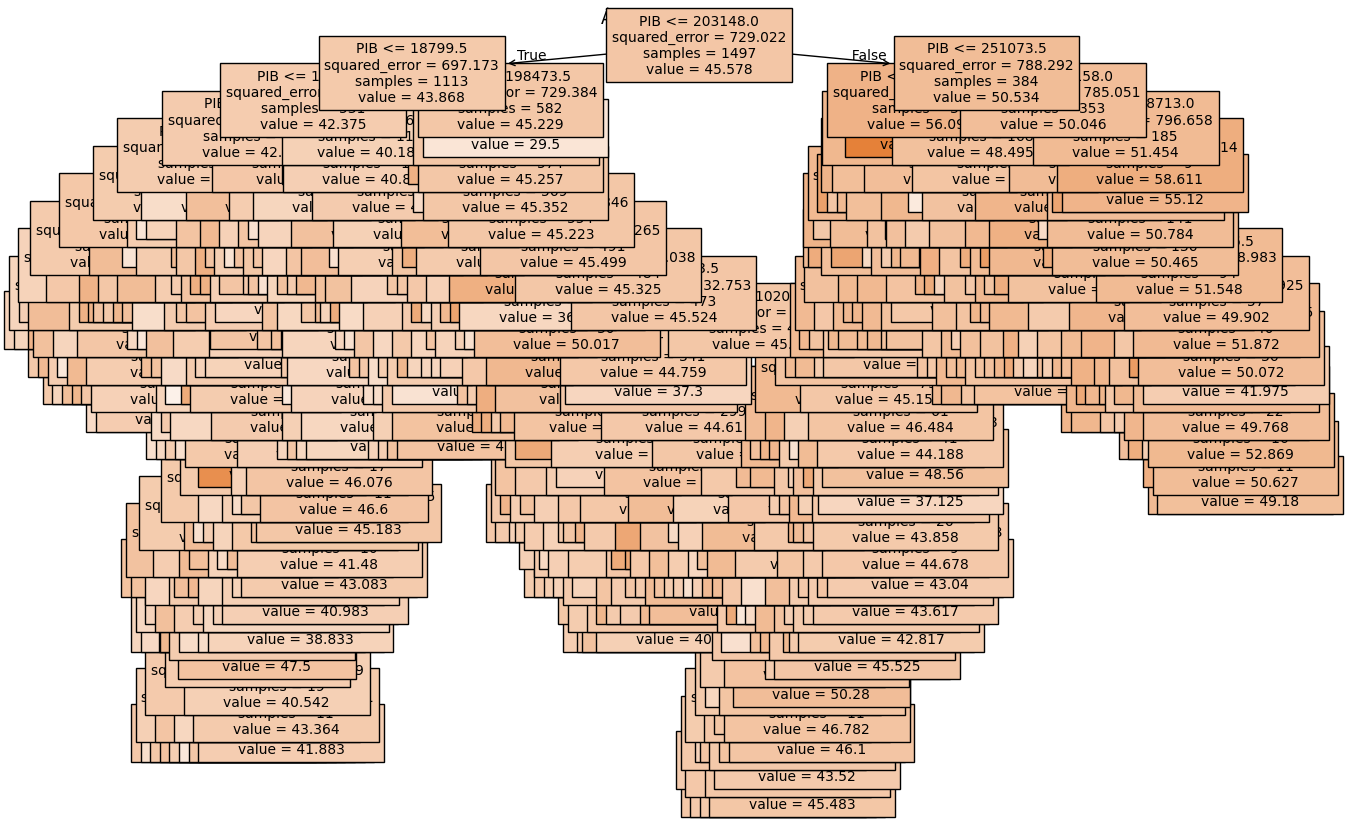

In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Crear el modelo de Árbol de Decisión
tree_model = DecisionTreeRegressor(random_state=42)

# Entrenar el modelo
tree_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_tree = tree_model.predict(X_test)

# Calcular RMSE y R²
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("RMSE (Árbol de Decisión):", rmse_tree)
print("R² (Árbol de Decisión):", r2_tree)

# Visualizar
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(tree_model, filled=True, feature_names=['PIB'], fontsize=10)
plt.title("Árbol de Decisión")
plt.show()

## **Random forest**

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Crear el modelo de Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_rf = rf_model.predict(X_test)

# Calcular RMSE y R²
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RMSE (Random Forest):", rmse_rf)
print("R² (Random Forest):", r2_rf)

RMSE (Random Forest): 33.51196604198905
R² (Random Forest): -0.5598184719578987


## **KNN**

In [20]:
from sklearn.neighbors import KNeighborsRegressor

# Crear el modelo KNN
knn_model = KNeighborsRegressor(n_neighbors=5)

# Entrenar el modelo
knn_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_knn = knn_model.predict(X_test)

# Calcular RMSE y R²
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("RMSE (KNN):", rmse_knn)
print("R² (KNN):", r2_knn)


RMSE (KNN): 31.82484649452374
R² (KNN): -0.4067174655891379


## **SVM**

In [21]:
from sklearn.svm import SVR

# Crear el modelo SVM
svm_model = SVR(kernel='rbf')

# Entrenar el modelo
svm_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_svm = svm_model.predict(X_test)

# Calcular RMSE y R²
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))
r2_svm = r2_score(y_test, y_pred_svm)

print("RMSE (SVM):", rmse_svm)
print("R² (SVM):", r2_svm)

RMSE (SVM): 28.861358915467868
R² (SVM): -0.15693189969945553


## **Comparación de modelos**

In [22]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM']
rmse_scores = [rmse, rmse_tree, rmse_rf, rmse_knn, rmse_svm]
r2_scores = [r2, r2_tree, r2_rf, r2_knn, r2_svm]

# Crear un DataFrame para visualizar los resultados
import pandas as pd
results = pd.DataFrame({'Model': models, 'RMSE': rmse_scores, 'R²': r2_scores})

print(results)

               Model       RMSE        R²
0  Linear Regression  26.977653 -0.010840
1      Decision Tree  33.779195 -0.584794
2      Random Forest  33.511966 -0.559818
3                KNN  31.824846 -0.406717
4                SVM  28.861359 -0.156932


## **Polinomial**

In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Crear un transformador polinómico de grado 2
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# Entrenar el modelo polinómico
model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

# Hacer predicciones con el modelo polinómico
y_pred_poly = model_poly.predict(X_poly_test)

# Evaluar el modelo polinómico
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("RMSE (Polinómico):", rmse_poly)
print("R² (Polinómico):", r2_poly)


RMSE (Polinómico): 26.870363124634085
R² (Polinómico): -0.0028161409157807515


#### **Polimonial pero probando varios grados**

C:\Users\Equipo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Equipo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Equipo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Equipo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Py

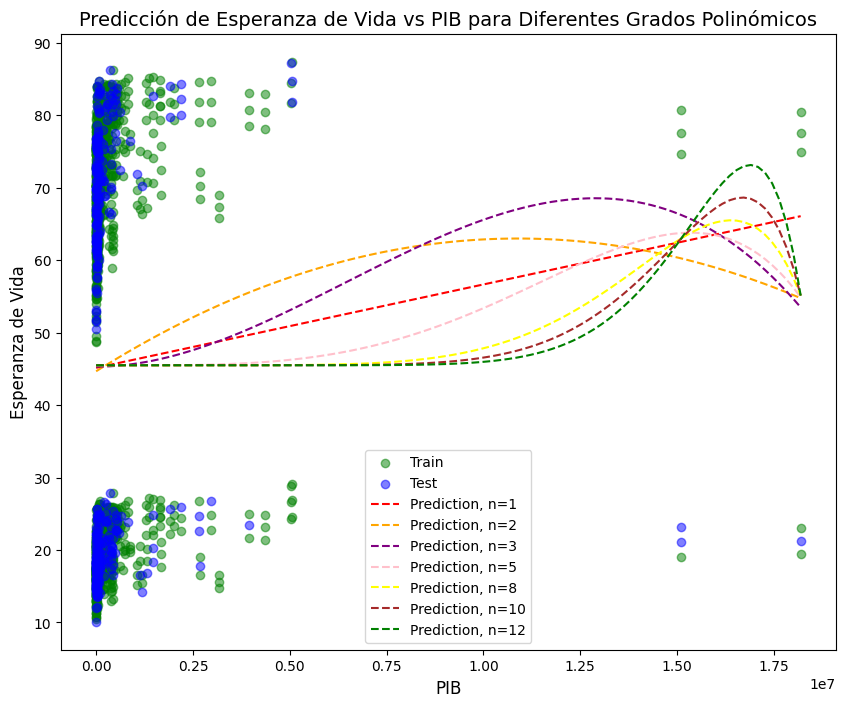

NameError: name 'polydegree' is not defined

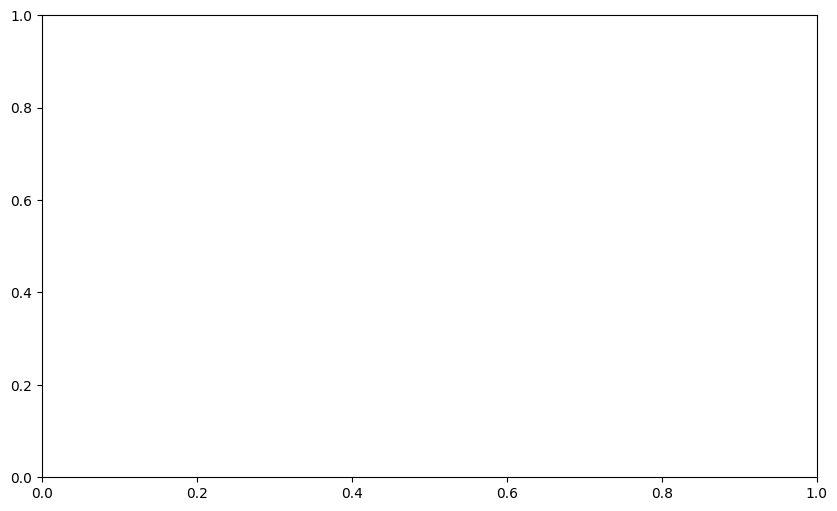

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Suponiendo que ya tienes el DataFrame df_combined con 'PIB' y 'Esperanza_de_vida'
X = df_combined[['PIB']]  # Variable independiente: PIB
y = df_combined['Esperanza_de_vida']  # Variable dependiente: Esperanza de vida

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el gráfico
plt.figure(figsize=(10, 8))

# Graficar los datos reales de entrenamiento y prueba
plt.scatter(X_train, y_train, color='green', label='Train', alpha=0.5)
plt.scatter(X_test, y_test, color='blue', label='Test', alpha=0.5)

# Definir los grados polinómicos a probar
degrees = [1, 2, 3, 5, 8, 10, 12]
colors = ['red', 'orange', 'purple', 'pink', 'yellow', 'brown', 'green']

# Entrenar y graficar los modelos polinómicos para diferentes grados
for degree, color in zip(degrees, colors):
    # Crear el transformador polinómico para el grado actual
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)
    
    # Crear el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    
    # Hacer predicciones en los datos de prueba
    y_pred = model.predict(X_poly_test)
    
    # Graficar la curva de predicción para el grado polinómico
    x_grid = np.linspace(np.min(X), np.max(X), 100).reshape(-1, 1)  # Crear una malla de valores de PIB
    x_poly_grid = poly.transform(x_grid)
    y_poly_pred = model.predict(x_poly_grid)
    
    # Graficar la predicción para este grado
    plt.plot(x_grid, y_poly_pred, linestyle='--', color=color, label=f'Prediction, n={degree}')

# Añadir título, etiquetas y leyenda
plt.title('Predicción de Esperanza de Vida vs PIB para Diferentes Grados Polinómicos', fontsize=14)
plt.xlabel('PIB', fontsize=12)
plt.ylabel('Esperanza de Vida', fontsize=12)
plt.legend()

# Mostrar el gráfico
plt.show()

# gráfico de error
fig, ax = plt.subplots(1,1, figsize=(10, 6))

ax.plot(polydegree, error_train, 'o-', label='Train')
ax.plot(polydegree, error_test, 'o-', label='Test')

ax.set_xlabel("n", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.legend()

## **Multivariable**

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Suponiendo que 'df_combined' tiene las columnas 'PIB' y 'Dim1'
X = df_combined[['PIB', 'Dim1']]  # Usamos 'Dim1' como la columna de sexo
y = df_combined['Esperanza_de_vida']

# Crear un transformador para 'Dim1' con OneHotEncoder para convertir categorías en variables dummy
preprocessor = ColumnTransformer(
    transformers=[
        ('sex', OneHotEncoder(), ['Dim1'])  # Codificamos 'Dim1' con OneHotEncoder
    ], 
    remainder='passthrough'  # Mantiene otras columnas como están
)

# Crear el modelo de regresión lineal
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo con RMSE y R²
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 26.89045869500023
R²: -0.0043166563975665095


## **Comparación predicciones vs datos reales**

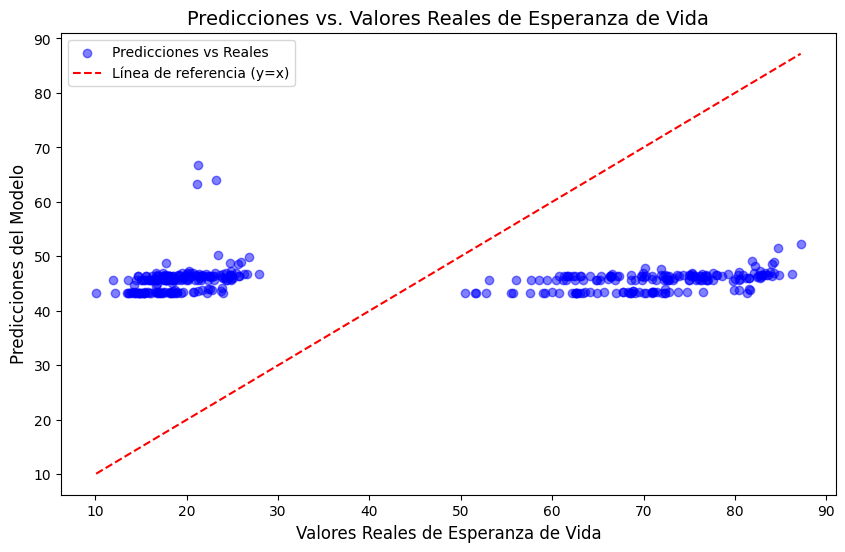

In [26]:
import matplotlib.pyplot as plt

# Graficar los valores reales vs. las predicciones
plt.figure(figsize=(10, 6))

# Graficar valores reales de esperanza de vida
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicciones vs Reales')

# Añadir una línea de referencia (y = x) para comparar las predicciones y los valores reales
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Línea de referencia (y=x)')

# Títulos y etiquetas
plt.title('Predicciones vs. Valores Reales de Esperanza de Vida', fontsize=14)
plt.xlabel('Valores Reales de Esperanza de Vida', fontsize=12)
plt.ylabel('Predicciones del Modelo', fontsize=12)

# Añadir leyenda
plt.legend()


## **Matriz de confusión**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np

# Suponiendo que tienes el df_combined con PIB y Esperanza de vida
# Convertir 'Esperanza_de_vida' en categorías
df_combined['Categoria_Esperanza'] = np.where(df_combined['Esperanza_de_vida'] > 30, 'Alta', 'Baja')

# Definir las variables dependiente e independiente
X = df_combined[['PIB']]  # Usamos PIB como la variable predictora
y = df_combined['Categoria_Esperanza']  # Variable dependiente: Alta/Baja esperanza de vida

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión logística (como clasificador)
model = LogisticRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Mostrar la matriz de confusión
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=model.classes_)
disp.plot(cmap='Blues')

plt.title('Matriz de Confusión - Predicción de Esperanza de Vida')
plt.show()

## **Validación cruzada**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Utilizamos el mismo df_combined y la misma transformación
# Definir las variables dependiente e independiente
X = df_combined[['PIB']]
y = df_combined['Categoria_Esperanza']  # Variable dependiente: Alta/Baja esperanza de vida

# Crear el modelo de regresión logística (clasificación)
model = LogisticRegression()

# Realizar validación cruzada (con 5 particiones)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

# Mostrar los resultados de la validación cruzada
print(f"Resultados de la validación cruzada: {cv_scores}")
print(f"Precisión promedio de la validación cruzada: {cv_scores.mean()}")

### **Estadísticas de resumen**


- **Media** (`np.mean()`): es la suma de todos los valores, dividida por el número de puntos.
 
$$\mu=\frac{1}{n} \sum_{i=1}^n x_i $$

- **Mediana** (`np.median()`): es el valor medio de un conjunto de datos. Es inmune a valores extremos o outliers. Para calcularla, se ordenan los datos y se elige el valor que queda en la mitad. 
 
- **Percentiles** (`np.percentile()`): el percentil $p$, corresponde al valor que es mayor al $p\%$ de los datos.


- **Varianza** (`np.var()`): promedio de la distancia cuadrática de los datos a la media. Es una medida de la dispersión de los datos.

$$\rm{Var}=\frac{1}{n} \sum_{i=1}^n (x_i-\bar{x})^2$$

- **Desviación estándar** (`np.std()`): es la raíz cuadrada de la varianza. Está en la misma escala de unidades que los datos.

$$\sigma=\sqrt{\frac{1}{n} \sum_{i=1}^n (x_i-\bar{x})^2}$$

- **Covarianza** (`np.cov()`): es una medida de cómo dos cantidades varían juntas.
Es la media del producto entre las diferencias de los valores respecto a la media.

$$\rm{Cov} (x,y)=\frac{1}{n} \sum_{i=1}^n (x_i-\bar{x})(y_i-\bar{y})$$

- **Coeficiente de correlación de Pearson** (`np.corrcoef`): para tener una medida más general y aplicable de la correlación entre dos variables, necesitamos que sea adimensional. Por lo tanto dividimos la covarianza por las desviaciones estándar de $x$ e $y$. Esto define el coeficiente de correlación de Pearson ($\rho$).

$$\rho=\frac{\rm{Cov} (x,y)}{\sigma_x \sigma_y}$$

### **RMSE Y R2:**
#### **Valores buenos o malos:**

- `RMSE bajo` = Buen modelo (idealmente más cercano a 0).

- `RMSE alto` = Mal modelo (cuanto mayor el RMSE, peor es el modelo).

- `R² cercano a 1` = Buen modelo.

- `R² cercano a 0 o negativo` = Mal modelo.

## **Otros ejemplos de gráficos**

In [ ]:
# EJEMPLOS:

#### barra
x = urgenciasRespiratorias['GlosaCausa'].unique()
y = urgenciasRespiratorias['GlosaCausa'].value_counts()

plt.bar(x,y)
plt.xticks(rotation=90)

#### barra
# sumando cantidad de sobrevivientes por gate
cantidad_survived = df.groupby('Pclass')['Survived'].sum()
sns.barplot(x=cantidad_survived.index, y=cantidad_survived.values)
plt.title('Cantidad de Sobrevivientes por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Sobrevivientes')
plt.show()

#### barra
grupos_edad = ['Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'De_65_y_mas']
total_por_grupo = urgenciasRespiratorias[grupos_edad].sum()
total_por_grupo.plot(kind='bar')

#### heatmap
correlacion = df[['Total', 'Registros validados']].corr()
import seaborn as sns
sns.heatmap(correlacion)

#### heatmap
sns.heatmap(corre, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('correlaciones')

#### Scatterplots e Histogramas
sns.pairplot(df)

#### Scatterplot color depende de una varial en este caso depth
sns.pairplot(data=oceanStudent, y_vars='Salnty', x_vars='T_degC', hue='Depthm', height=5)

#### Grafico de dispersion agregando puntos (en este caso ver datos de prueba y entrenamiento)
#Dividimos el dataframe de entrada
train, test = train_test_split(oceanStudent, test_size=0.25, random_state=2)
##
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
plt.plot(test['T_degC'], test['Salnty'], '.', markersize=3, color='orange', zorder=1, label='Test')
plt.plot(train['T_degC'], train['Salnty'], '.', markersize=3, color='blue', zorder=0, label='Train')
ax.set_xlabel('Temperatura',fontsize=14)
ax.set_ylabel('Salinidad',fontsize=14)
ax.legend()


#### Barra
# Contar la cantidad de sobrevivientes (1) y no sobrevivientes (0)
sobrevivientes_count = df['Survived'].value_counts()
# Crear un gráfico de barras para visualizar la cantidad de sobrevivientes y no sobrevivientes
sns.barplot(x=sobrevivientes_count.index, y=sobrevivientes_count.values, palette='pastel')

In [ ]:
# EJEMPLO grafico dispersion diferenciar color por especie
sns.scatterplot(data=penguins, x="culmen_length_mm", y="flipper_length_mm", hue="species")
plt.title("Relación entre largo de aleta y largo de culmen")
plt.xlabel("Largo del culmen (mm)")
plt.ylabel("Largo de aleta (mm)")
plt.legend(title="Especie")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#Ejemplo histograma
sns.histplot(data=penguins, x="body_mass_g", hue="sex", element="step", bins=30)
plt.title("Distribución del peso corporal por sexo")
plt.xlabel("Peso corporal (g)")
plt.ylabel("Frecuencia")
plt.legend(title="Sexo")
plt.grid(alpha=0.3)
plt.show()

### **SNS**

In [ ]:
datasns = sns.load_dataset('titanic') # cargar dataset con sns

# graficar una columna del df con sns - dispersion
fig, ax = plt.subplots(1, 1, figsize=(9,3))
ax = sns.scatterplot(data.Age)
plt.xlabel('muestra')
plt.ylabel('edad')

# graficar una columna del df con sns - histograma/barra
sns.displot(data.Age, kde=False, bins=20)
plt.xlabel('edad')
plt.ylabel('cantidad')

# graficar una columna del df con sns - histograma
fig, ax = plt.subplots(1, 1, figsize=(7,3))
ax = sns.histplot(data=data, x='Age', bins=20)
ax.set_xlabel('edad')
ax.set_ylabel('cantidad')
ax.set(xlim=(0, 90))

# graficar una columna del df con sns - histograma con linea
fig, ax = plt.subplots(1, 1, figsize=(7,3))
ax = sns.histplot(data=data, x='Age', bins=20, kde=True)
ax.set_xlabel('edad')
ax.set_ylabel('cantidad')
ax.set(xlim=(0, 90))

# crear columnas con calculos 
dat['pct_D'] = dat['votes_D_2020']/dat['votes_total_2020']*100
dat['pct_R'] = dat['votes_R_2020']/dat['votes_total_2020']*100

### **Graficar por separado**

In [ ]:
data = pd.read_csv('datasaurus.csv')
datasets = data.dataset.unique()

fig, axs = plt.subplots(4, 4)

for i in range(len(datasets)):
    # selecciona el set
    data_select = data[data['dataset']==datasets[i]]
    # grafica
    axs[int(np.floor(i/4)), i%4].plot(data_select['x'], data_select['y'], '.')

# Graficar por encima
data_select = data[data['dataset']=='x_shape']
plt.plot(data_select['x'], data_select['y'], 'x')
data_select = data[data['dataset']=='dino']
plt.plot(data_select['x'], data_select['y'], '.')